In [1]:
import random 
import warnings 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter,sosfiltfilt,savgol_filter,find_peaks
warnings.filterwarnings("ignore")
SEED=42
random.seed(SEED)
np.random.seed(SEED)
sns.set_style("whitegrid")

In [2]:
FS=125 
WINDOW_SECONDS=8 
WINDOW_SIZE=WINDOW_SECONDS*FS
STEP_SECONDS=4 
STEP_SIZE=STEP_SECONDS*FS
PATIENT_IDS=[1,2,3,4,5]



In [3]:
FS = 125                 # PPG sampling frequency
WINDOW_SECONDS = 8       # Each PPG sample/window is 8 seconds
WINDOW_SIZE = FS * WINDOW_SECONDS
STEP_SECONDS = 4
STEP_SIZE = FS * STEP_SECONDS

# Small classroom demo: first 5 patient records
PATIENT_IDS = [1, 2, 3, 4, 5]

BASE_URL = (
    "https://physionet.org/files/bidmc/1.0.0/bidmc_csv"
)

print("Sampling frequency:", FS, "Hz")
print("Window size:", WINDOW_SECONDS, "seconds")
print("Samples per window:", WINDOW_SIZE)

Sampling frequency: 125 Hz
Window size: 8 seconds
Samples per window: 1000


In [4]:
def load_patient(patient_id):
    """
    Load a single patient record from the BIDMC dataset.
    """
    signal_url = f"{BASE_URL}/bidmc_{patient_id:02d}_Signals.csv"
    numeric_url = f"{BASE_URL}/bidmc_{patient_id:02d}_Numerics.csv"
    signals = pd.read_csv(signal_url)
    numerics = pd.read_csv(numeric_url)
    signals.columns=signals.columns.str.strip()
    numerics.columns=numerics.columns.str.strip()
    return signals, numerics
all_patient_data=[]
for patient_id in PATIENT_IDS:
    signals, numerics = load_patient(patient_id)
    all_patient_data.append({
        "patient_id": patient_id,
        "signals": signals,
        "numerics": numerics,
    })
    print(f"Loaded patient {patient_id}: {signals.shape[0]} samples, {numerics.shape[0]} numeric records")

Loaded patient 1: 60001 samples, 481 numeric records
Loaded patient 2: 60001 samples, 481 numeric records
Loaded patient 3: 60001 samples, 481 numeric records
Loaded patient 4: 60001 samples, 481 numeric records
Loaded patient 5: 60001 samples, 481 numeric records


In [5]:
example_signals=all_patient_data[1]['signals']
example_numerics=all_patient_data[1]['numerics']

print(example_signals.columns.tolist())
print(example_numerics.columns.tolist())
print(example_signals.head())
print(example_numerics.head())

['Time [s]', 'II', 'PLETH', 'RESP', 'V', 'AVR']
['Time [s]', 'HR', 'PULSE', 'RESP', 'SpO2']
   Time [s]       II    PLETH     RESP        V      AVR
0     0.000  0.14453  0.63636  0.04059  0.83529  0.74414
1     0.008  0.15625  0.65689  0.04059  0.83529  0.74023
2     0.016  0.15625  0.67351  0.04059  0.84118  0.74023
3     0.024  0.16016  0.68817  0.04059  0.84510  0.73438
4     0.032  0.16016  0.69990  0.04059  0.84510  0.73438
   Time [s]  HR  PULSE  RESP  SpO2
0         0  93     92    16   100
1         1  93     93    16   100
2         2  93     93    16   100
3         3  94     94    16   100
4         4  94     94    16   100


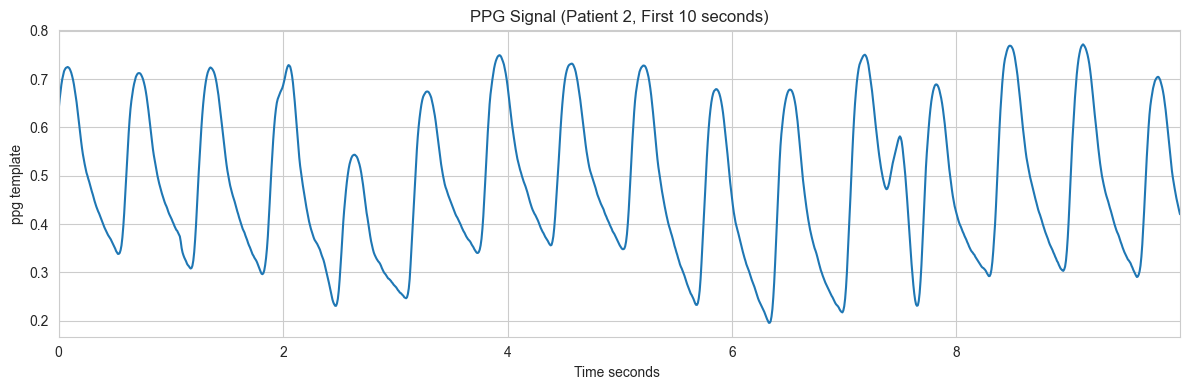

In [6]:
duration=10 
number_of_samples=duration*FS
time=example_signals['Time [s]'][:number_of_samples]
ppg=example_signals['PLETH'][:number_of_samples]

plt.figure(figsize=(12,4))
plt.plot(time,ppg)
plt.title("PPG Signal (Patient 2, First 10 seconds)")
plt.xlabel('Time seconds ')
plt.ylabel('ppg template')
plt.xlim(time.iloc[0],time.iloc[-1])
plt.tight_layout()
plt.show()

In [7]:
ACTIONS={
    0:"Raw Signal",
    1:"Moving Average",
    2:"Savitzky-Golay",
    3:"Butterworth Bandpass"
}

N_ACTIONS=len(ACTIONS)
for action_id,action_name in ACTIONS.items():
    print(f"{action_id}: {action_name}")

0: Raw Signal
1: Moving Average
2: Savitzky-Golay
3: Butterworth Bandpass


In [8]:
def moving_average_filter(signal, window=7):
    kernel = np.ones(window) / window

    filtered = np.convolve(
        signal,
        kernel,
        mode="same"
    )

    return filtered


def savgol_ppg_filter(signal):
    """
    Smooth the signal while preserving the shape of PPG peaks.
    """
    return savgol_filter(
        signal,
        window_length=21,
        polyorder=3
    )


def butterworth_filter(signal, fs=125):
    """
    PPG heart-rate frequency range:
    approximately 0.5 to 5 Hz.
    """

    sos = butter(
        N=4,
        Wn=[0.5, 5.0],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    return sosfiltfilt(sos, signal)


def apply_action(signal, action):
    """
    Apply the filter selected by the RL agent.
    """

    if action == 0:
        return signal.copy()

    elif action == 1:
        return moving_average_filter(signal)

    elif action == 2:
        return savgol_ppg_filter(signal)

    elif action == 3:
        return butterworth_filter(signal, FS)

    else:
        raise ValueError("Invalid action")

In [9]:
def estimate_heart_rate(signal,fs=125):
    signal=np.array(signal,dtype=float)
    normalized_signal=(signal-np.mean(signal))/(np.std(signal)+1e-8)
    
    minimum_distance=int(0.5*fs)
    peaks,_=find_peaks(normalized_signal,distance=minimum_distance,prominence=0.35)
    if len(peaks)<2:
        return np.nan,peaks 
    
    peak_intervals=np.diff(peaks)/fs
    median_interval=np.median(peak_intervals)
    estimated_hr=60/median_interval
    
    
    if  estimated_hr <35 or estimated_hr > 220 : 
        return np.nan ,peaks 
    
    return estimated_hr,peaks 
    

In [10]:
def calculate_noise_score(signal):
    smooth_signal=savgol_filter(signal,window_length=31,polyorder=3)
    high_frequency_part=signal-smooth_signal
    score=(np.std(high_frequency_part)/np.std(signal)+1e-8)
    
    return score

create ppg windows 

In [11]:
def create_window_dataset(all_patient_data):
    rows=[]
    
    for patient_data in all_patient_data:
        patient_id=patient_data['patient_id']
        signals=patient_data['signals'].copy()
        numerics=patient_data['numerics'].copy()
        
        signal_time=pd.to_numeric(signals['Time [s]'],errors='coerce').to_numpy()
        
        ppg_signal=pd.to_numeric(signals['PLETH'],errors='coerce').interpolate().bfill().ffill().to_numpy()
        
        numeric_time=pd.to_numeric(numerics['Time [s]'],errors='coerce').to_numpy()
        
        reference_pulse=pd.to_numeric(numerics['PULSE'],errors='coerce').to_numpy()
        for start in range(0,len(ppg_signal)-WINDOW_SIZE+1,STEP_SIZE):
            end=start+WINDOW_SIZE
            window_ppg=ppg_signal[start:end]
            window_time=signal_time[start:end]
            
            start_time=signal_time[start]
            end_time=signal_time[end-1]
            
            mask=(numeric_time>=start_time)&(numeric_time<=end_time)
            
            pulse_values=reference_pulse[mask]
            pulse_values=pulse_values[np.isfinite(pulse_values)]
            
            if len(pulse_values)==0:
                continue
            
            reference_hr=np.median(pulse_values)
            
            if not 35 <= reference_hr <= 220:
                continue
            
            noise_score=calculate_noise_score(window_ppg)
            rows.append({
                "patient_id":patient_id,
                "start_time":start_time,
                "end_time":end_time,
                "mid_time":window_time[WINDOW_SIZE//2],
                "ppg_signal":window_ppg,
                "reference_hr":reference_hr,
                "noise_score":noise_score
            })
    return pd.DataFrame(rows) 



window_df=create_window_dataset(all_patient_data)
print(len(window_df)) 
display(window_df.drop(columns=['ppg_signal']).head(10))      

593


,patient_id,start_time,end_time,mid_time,reference_hr,noise_score
0,1,0.0,7.992,4.0,93.0,0.121155
1,1,4.0,11.992,8.0,94.0,0.123468
2,1,8.0,15.992,12.0,94.0,0.120951
3,1,12.0,19.992,16.0,94.0,0.119533
4,1,16.0,23.992,20.0,94.0,0.123212
5,1,20.0,27.992,24.0,94.0,0.126791
6,1,24.0,31.992,28.0,94.0,0.128007
7,1,28.0,35.992,32.0,94.0,0.130413
8,1,32.0,39.992,36.0,94.0,0.133665
9,1,36.0,43.992,40.0,94.0,0.134126


In [12]:
STATE_NAMES={
    0:"Low Noise",
    1:"Medium Noise",
    2:"High Noise"} 


q1=window_df["noise_score"].quantile(0.33)
q2=window_df['noise_score'].quantile(0.66)

def noise_to_state(noise_score):
    if noise_score <= q1 : 
        return 0 
    
    elif noise_score <= q2 :
        return 1 
    else : 
        return 2 
    
window_df['state'] =window_df['noise_score'].apply(noise_to_state)

window_df['state_name']=window_df['state'].map(STATE_NAMES)
print("First threshold:",round(q1,4))
print("Second threshold:",round(q2,4))

print(window_df['state_name'].value_counts())

First threshold: 0.0711
Second threshold: 0.0944
state_name
High Noise      202
Low Noise       196
Medium Noise    195
Name: count, dtype: int64


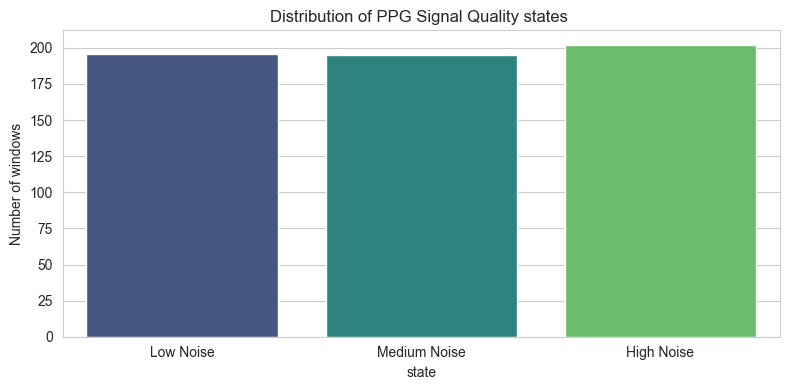

In [13]:
plt.figure(figsize=(8,4))
sns.countplot(data=window_df,x='state_name',order=['Low Noise','Medium Noise','High Noise'],palette='viridis')
plt.title("Distribution of PPG Signal Quality states ")
plt.xlabel('state')
plt.ylabel('Number of windows')
plt.tight_layout()
plt.show()

In [14]:
def calculate_reward(ppg_window,action,reference_hr):
    filtered_signal=apply_action(ppg_window,action)
    estimated_hr,peaks=estimate_heart_rate(filtered_signal,FS)
    
    if np.isnan(estimated_hr):
        return -50.0 ,np.nan
    error=abs(estimated_hr-reference_hr)
    
    error=min(error,50)
    reward =-error 
    return reward ,estimated_hr 

Precomputed error 

In [15]:
reward_matrix=np.zeros((len(window_df),N_ACTIONS))

estimated_hr_matrix=np.zeros((len(window_df),N_ACTIONS))
for row_position,(_,row) in enumerate(window_df.iterrows()):
    ppg_window=row['ppg_signal']
    reference_hr=row['reference_hr']
    
    for action in range(N_ACTIONS):
        reward,estimated_hr=calculate_reward(ppg_window,action,reference_hr)
        reward_matrix[row_position,action]=reward
        estimated_hr_matrix[row_position,action]=estimated_hr
        
print(reward_matrix.shape)
print(estimated_hr_matrix.shape)

for action in range(N_ACTIONS):
    print(f"Action {action} ({ACTIONS[action]}): Mean Reward = {reward_matrix[:,action].mean():.2f}, Mean Estimated HR = {np.nanmean(estimated_hr_matrix[:,action]):.2f}")

(593, 4)
(593, 4)
Action 0 (Raw Signal): Mean Reward = -1.52, Mean Estimated HR = 89.64
Action 1 (Moving Average): Mean Reward = -1.54, Mean Estimated HR = 89.74
Action 2 (Savitzky-Golay): Mean Reward = -1.57, Mean Estimated HR = 89.68
Action 3 (Butterworth Bandpass): Mean Reward = -1.41, Mean Estimated HR = 89.34


In [16]:
TRAIN_PATIENTS=[1,2,3,4]
TEST_PATIENTS=[5]
train_mask=window_df['patient_id'].isin(TRAIN_PATIENTS).to_numpy()
test_mask=window_df['patient_id'].isin(TEST_PATIENTS).to_numpy()

test_indices=np.where(test_mask)[0]
train_indices=np.where(train_mask)[0]

print(len(train_indices))
print(len(test_indices))
print(TRAIN_PATIENTS)
print(TEST_PATIENTS)

474
119
[1, 2, 3, 4]
[5]


Observe noise state
        ↓
Select filter using ε-greedy
        ↓
Estimate heart rate
        ↓
Receive reward
        ↓
Episode ends

In [17]:
N_STATES=3 
N_ACTIONS=2

Q=np.zeros((N_STATES, N_ACTIONS))
visit_count=np.zeros((N_STATES, N_ACTIONS),dtype=int) 
epsilon=1.0 
epsilon_min=0.05 
epsilon_decay=0.98
number_of_epochs=150

reward_history=[]
epsilon_history=[]

print("Initial Q-table:")
print(Q)


Initial Q-table:
[[0. 0.]
 [0. 0.]
 [0. 0.]]


In [18]:
def epsilon_greedy_action(state,Q,epsilon):
    if np.random.random() < epsilon:
        action = np.random.randint(N_ACTIONS)
        decision='Exploration'
        
    else:
        maximum_q =np.max(Q[state])
        
        best_actions=np.flatnonzero(Q[state]==maximum_q)
        
        
        action=np.random.choice(best_actions)
        decision='Exploitation'
    return action, decision

epsilon greedy channel

In [19]:
# Initialize the agent and training parameters
N_STATES = 3
N_ACTIONS = 2
number_of_epochs = 150

Q = np.zeros((N_STATES, N_ACTIONS))
visit_count = np.zeros((N_STATES, N_ACTIONS), dtype=int)
reward_history = []
epsilon_history = []

epsilon = 1.0       # Initial probability of choosing a random action
epsilon_min = 0.05  # Keep at least 5% exploration
epsilon_decay = 0.98

if len(train_indices) == 0:
    raise ValueError("No training samples found. Check TRAIN_PATIENTS and patient_id values.")

for epoch in range(number_of_epochs):
    shuffled_indices = np.random.permutation(train_indices)
    epoch_rewards = []
    exploration_count = 0
    exploitation_count = 0
    
    for data_index in shuffled_indices:
        state = int(window_df.iloc[data_index]['state'])
        action, decision = epsilon_greedy_action(state, Q, epsilon)
        if decision == 'Exploration':
            exploration_count += 1
        else:
            exploitation_count += 1
            
            
        reward = reward_matrix[data_index, action]
        G = reward
        visit_count[state, action] += 1
        learning_rate = 1 / visit_count[state, action]
        
        
        Q[state, action] += learning_rate * (G - Q[state, action])
        
        epoch_rewards.append(reward)
    average_reward = np.mean(epoch_rewards)
    reward_history.append(average_reward)
    epsilon_history.append(epsilon)
    
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{number_of_epochs}: Average Reward = {average_reward:.2f}, Epsilon = {epsilon:.4f}, Exploration = {exploration_count}, Exploitation = {exploitation_count}")
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
        

Epoch 1/150: Average Reward = -1.45, Epsilon = 1.0000, Exploration = 474, Exploitation = 0
Epoch 5/150: Average Reward = -1.43, Epsilon = 0.9224, Exploration = 443, Exploitation = 31
Epoch 10/150: Average Reward = -1.48, Epsilon = 0.8337, Exploration = 386, Exploitation = 88
Epoch 15/150: Average Reward = -1.45, Epsilon = 0.7536, Exploration = 361, Exploitation = 113
Epoch 20/150: Average Reward = -1.42, Epsilon = 0.6812, Exploration = 332, Exploitation = 142
Epoch 25/150: Average Reward = -1.44, Epsilon = 0.6158, Exploration = 287, Exploitation = 187
Epoch 30/150: Average Reward = -1.44, Epsilon = 0.5566, Exploration = 280, Exploitation = 194
Epoch 35/150: Average Reward = -1.46, Epsilon = 0.5031, Exploration = 237, Exploitation = 237
Epoch 40/150: Average Reward = -1.43, Epsilon = 0.4548, Exploration = 212, Exploitation = 262
Epoch 45/150: Average Reward = -1.44, Epsilon = 0.4111, Exploration = 193, Exploitation = 281
Epoch 50/150: Average Reward = -1.43, Epsilon = 0.3716, Exploratio

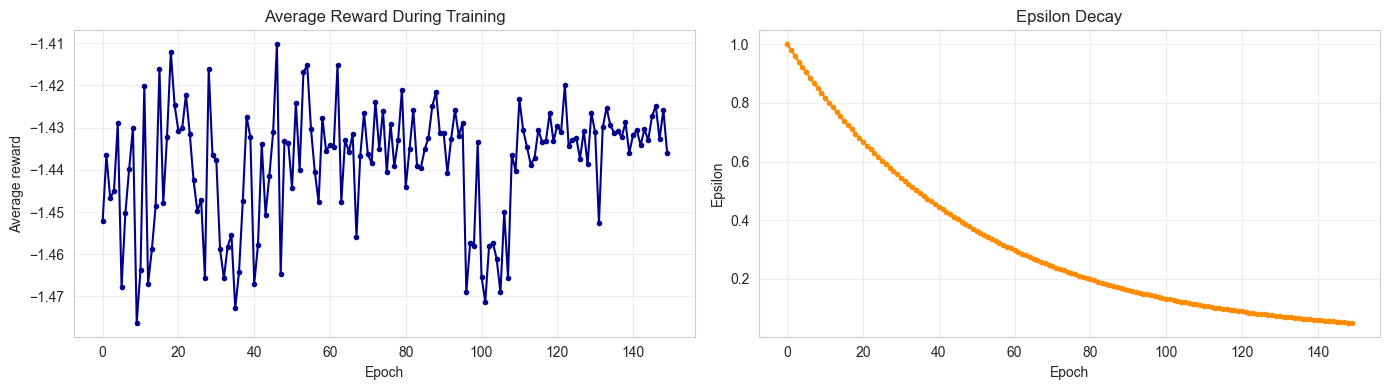

In [20]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4)
)

axes[0].plot(
    reward_history,
    color="darkblue",
    marker="o",
    markersize=3
)

axes[0].set_title(
    "Average Reward During Training"
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Average reward")
axes[0].grid(alpha=0.3)

axes[1].plot(
    epsilon_history,
    color="darkorange",
    marker="o",
    markersize=3
)

axes[1].set_title(
    "Epsilon Decay"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Epsilon")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
q_table = pd.DataFrame(
    Q,
    index=[
        STATE_NAMES[state]
        for state in range(N_STATES)
    ],
    columns=[
        ACTIONS[action]
        for action in range(N_ACTIONS)
    ]
)

print("Learned Q-table:")
display(q_table.round(3))

Learned Q-table:


,Raw Signal,Moving Average
Low Noise,-2.702,-2.767
Medium Noise,-1.574,-1.631
High Noise,-0.766,-0.757


In [29]:
learned_policy=np.argmax(Q,axis=1)
policy_rows=[]

for state in range(Q.shape[0]):
    best_action=learned_policy[state]
    policy_rows.append({
        'State':STATE_NAMES[state],
        'Selected_action':ACTIONS[best_action],
        'Estimated reward':Q[state,best_action],
        'Estimated HR error':-Q[state,best_action]
    })

policy_df=pd.DataFrame(policy_rows)
display(policy_df.round(3))

,State,Selected_action,Estimated reward,Estimated HR error
0,Low Noise,Raw Signal,-2.702,2.702
1,Medium Noise,Raw Signal,-1.574,1.574
2,High Noise,Moving Average,-0.757,0.757


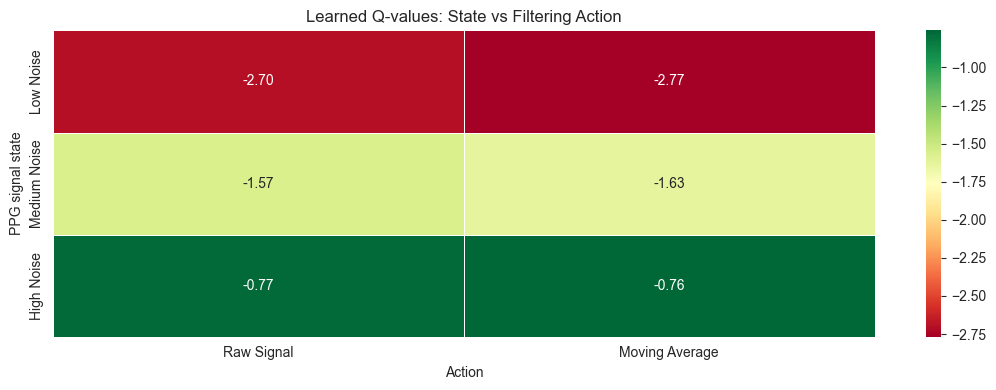

In [30]:
plt.figure(figsize=(11, 4))

sns.heatmap(
    q_table,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title(
    "Learned Q-values: State vs Filtering Action"
)
plt.xlabel("Action")
plt.ylabel("PPG signal state")
plt.tight_layout()
plt.show()


In [40]:
def evaluate_policy(indices,policy):
    errors = []
    predictions=[]
    references=[]
    selected_actions=[]
    
    for data_index in indices:
        row=window_df.iloc[data_index]
        state=int(row['state'])
        action=int(policy[state])
        estimated_hr=estimated_hr_matrix[data_index,action]
        reference_hr=row['reference_hr']
        if np.isnan(estimated_hr):
            error=50.0 
        else : 
            error=abs(estimated_hr-reference_hr)
            
        errors.append(error)
        predictions.append(estimated_hr)
        references.append(reference_hr)
        selected_actions.append(ACTIONS[action])

    return {
        'MAE':np.mean(errors),
        'errors':np.array(errors),
        'predictions':np.array(predictions),
        'references':np.array(references),
        'actions':selected_actions
    }

mc_result=evaluate_policy(test_indices,learned_policy)
print('MC e-greedy test MAE:',round(mc_result['MAE'],2),'BPM')

MC e-greedy test MAE: 1.87 BPM


In [41]:

comparison_rows=[]
learned_policy=np.argmax(Q,axis=1)
mc_result=evaluate_policy(test_indices,learned_policy)

for action in range(N_ACTIONS):
    fixed_policy=np.full(N_STATES,action)
    result=evaluate_policy(test_indices,fixed_policy)
    comparison_rows.append({
        'Policy':f"Fixed Action {action} ({ACTIONS[action]})",
        'MAE (BPM)':result['MAE']
    })
    
comparison_rows.append({
    'Policy':'MC epsilon-greedy',
    'MAE (BPM)':mc_result['MAE']
})

comparison_df=pd.DataFrame(comparison_rows).sort_values("MAE (BPM)")
display(comparison_df.round(3))

,Policy,MAE (BPM)
1,Fixed Action 1 (Moving Average),1.862
2,MC epsilon-greedy,1.871
0,Fixed Action 0 (Raw Signal),1.875


In [42]:
display(comparison_df.round(6))

,Policy,MAE (BPM)
1,Fixed Action 1 (Moving Average),1.862097
2,MC epsilon-greedy,1.871492
0,Fixed Action 0 (Raw Signal),1.874723


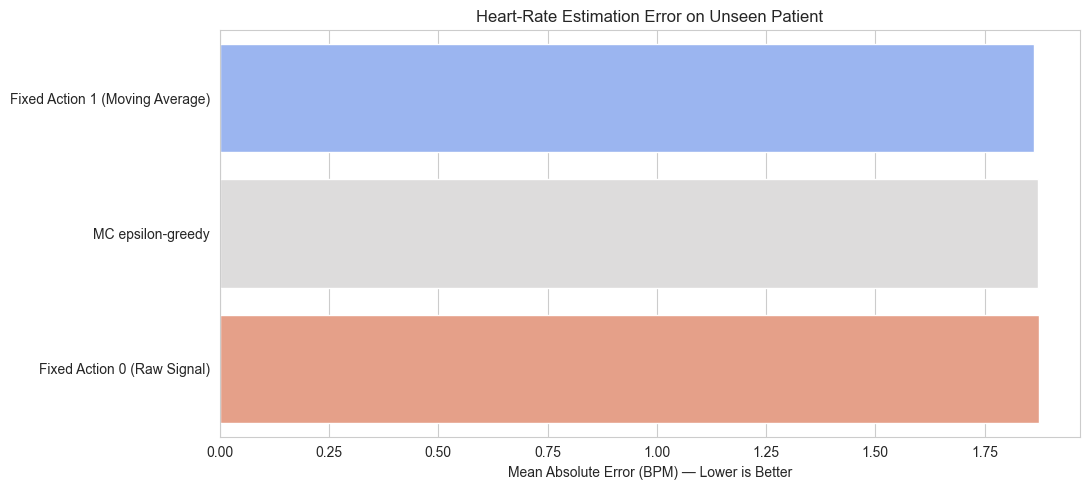

In [44]:
plt.figure(figsize=(11, 5))

sns.barplot(
    data=comparison_df,
    x="MAE (BPM)",
    y="Policy",
    hue="Policy",
    palette="coolwarm",
    legend=False
)

plt.title(
    "Heart-Rate Estimation Error on Unseen Patient"
)
plt.xlabel("Mean Absolute Error (BPM) — Lower is Better")
plt.ylabel("")
plt.tight_layout()
plt.show()

visual example 

In [46]:
# Select a high-noise test window
high_noise_test_indices = [
    index
    for index in test_indices
    if window_df.iloc[index]["state"] == 2
]

if len(high_noise_test_indices) > 0:
    example_index = high_noise_test_indices[0]
else:
    example_index = test_indices[0]

example_row = window_df.iloc[example_index]

example_state = int(example_row["state"])
example_action = int(
    learned_policy[example_state]
)

raw_ppg = example_row["ppg_signal"]

filtered_ppg = apply_action(
    raw_ppg,
    example_action
)

raw_hr, raw_peaks = estimate_heart_rate(
    raw_ppg,
    FS
)

filtered_hr, filtered_peaks = estimate_heart_rate(
    filtered_ppg,
    FS
)

reference_hr = example_row["reference_hr"]

window_time = (
    np.arange(len(raw_ppg)) / FS
)

print("Patient:", example_row["patient_id"])
print("State:", STATE_NAMES[example_state])
print("Agent selected:", ACTIONS[example_action])
print("Reference HR:", round(reference_hr, 2), "BPM")
print("Raw estimated HR:", round(raw_hr, 2), "BPM")
print(
    "Filtered estimated HR:",
    round(filtered_hr, 2),
    "BPM"
)

Patient: 5
State: High Noise
Agent selected: Moving Average
Reference HR: 98.0 BPM
Raw estimated HR: 98.68 BPM
Filtered estimated HR: 98.68 BPM


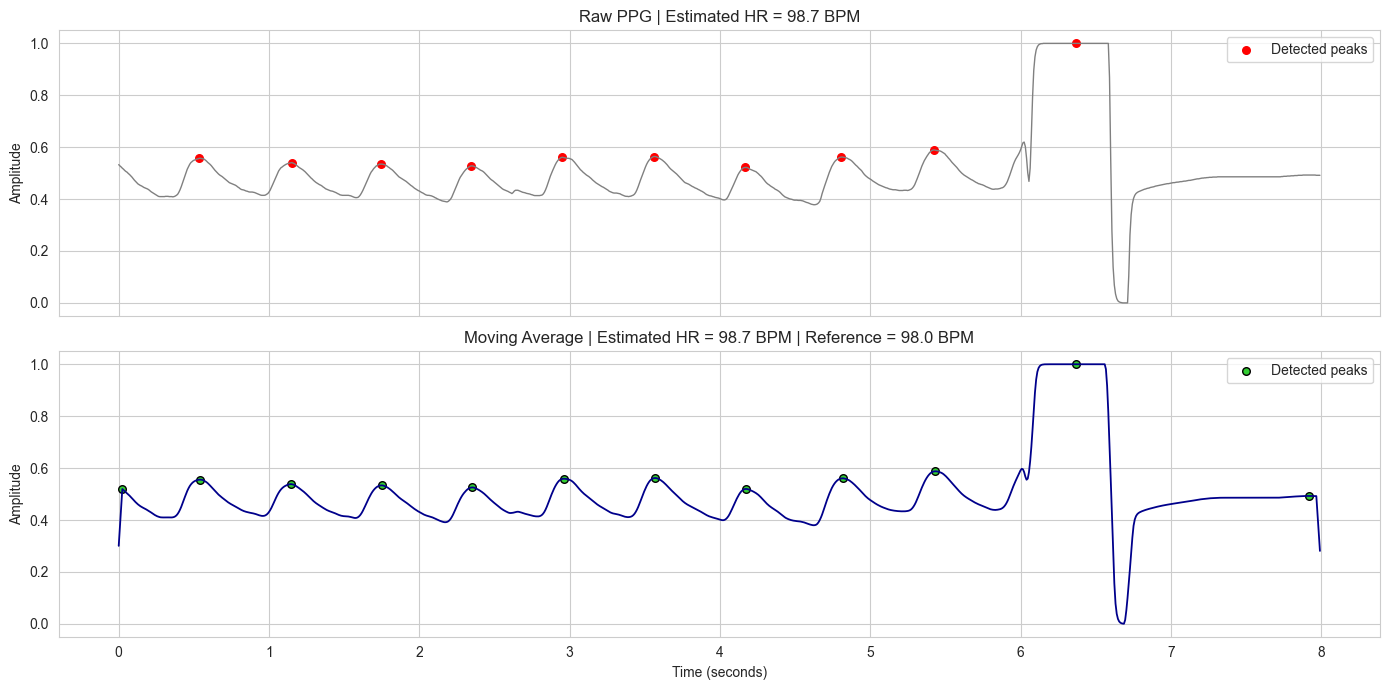

In [47]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 7),
    sharex=True
)

axes[0].plot(
    window_time,
    raw_ppg,
    color="gray",
    linewidth=1
)

axes[0].scatter(
    window_time[raw_peaks],
    raw_ppg[raw_peaks],
    color="red",
    s=30,
    label="Detected peaks"
)

axes[0].set_title(
    f"Raw PPG | Estimated HR = {raw_hr:.1f} BPM"
)
axes[0].set_ylabel("Amplitude")
axes[0].legend()

axes[1].plot(
    window_time,
    filtered_ppg,
    color="darkblue",
    linewidth=1.3
)

axes[1].scatter(
    window_time[filtered_peaks],
    filtered_ppg[filtered_peaks],
    color="limegreen",
    edgecolor="black",
    s=30,
    label="Detected peaks"
)

axes[1].set_title(
    f"{ACTIONS[example_action]} | "
    f"Estimated HR = {filtered_hr:.1f} BPM | "
    f"Reference = {reference_hr:.1f} BPM"
)

axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Amplitude")
axes[1].legend()

plt.tight_layout()
plt.show()